In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# Carregamento e limpeza do dataset
df = pd.read_csv('Live_20210128.csv')
df = df.drop(columns=['Column1', 'Column2', 'Column3', 'Column4'], errors='ignore')
df['status_published'] = pd.to_datetime(df['status_published'], errors='coerce')

# Apenas variáveis numéricas

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

# Número de elementos

In [ ]:
n = len(numeric_df)
print(f"\n1. Número de elementos: {n}")


1. Número de elementos: 7050


# Regressão Linear

Selecionar variáveis independentes e dependente

In [ ]:
x = df[['num_reactions']].values
y = df['num_comments'].values

Criar e treinar modelo

In [ ]:
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.29]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[38841.25]


Mostrar coeficientes

In [ ]:
print("Coeficiente (inclinação):", model.coef_[0])
print("Intercepto:", model.intercept_)

Coeficiente (inclinação): 0.29007362592452257
Intercepto: 157.60510847494652


Previsão e Visualização

In [ ]:
y_pred = model.predict(x)

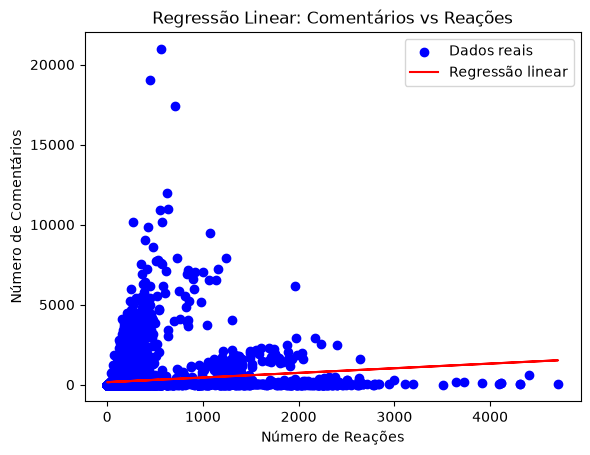

In [ ]:
plt.scatter(x, y, color='blue', label='Dados reais')
plt.plot(x, y_pred, color='red', label='Regressão linear')
plt.xlabel("Número de Reações")
plt.ylabel("Número de Comentários")
plt.title("Regressão Linear: Comentários vs Reações")
plt.legend()
plt.show()